# CVA, DVA, and BCVA Estimation

This notebook implements a Credit Valuation Adjustment (CVA) and Debt Valuation Adjustment (DVA) framework for a stylized interest rate swap (IRS), using the regime-conditional implied PD term structures calibrated in Notebook 4.

The underlying instrument is a 5-year fixed-for-floating IRS with notional $100 million. The exposure profile — the expected positive and negative mark-to-market value of the swap over its life — is generated via Monte Carlo simulation under a Hull-White one-factor interest rate model, calibrated to the Treasury yield data in the main dataset.

## Recall: CVA and DVA

**Unilateral CVA (UCVA)** measures the cost to us of the counterparty's default risk, assuming we ourselves are default-free:

$$UCVA = -LGD_C \sum_{t} DF(t) \cdot EPE(t) \cdot q_C(t-1, t)$$

**Unilateral DVA (UDVA)** measures the benefit to us of our own default risk, from the counterparty's perspective:

$$UDVA = -LGD_B \sum_{t} DF(t) \cdot ENE(t) \cdot q_B(t-1, t)$$

**Bilateral CVA (BCVA)** accounts for the possibility that either party may default first, incorporating survival adjustments for both sides. Under the sign convention adopted here:

- UCVA is reported as a negative adjustment
- UDVA is reported as a positive adjustment

Therefore: 

$$BCVA = CVA + DVA \\ = -LGD_C \sum_{t} DF(t) \cdot EPE(t) \cdot q_C(t-1,t) \cdot S_B(t) - LGD_B \sum_{t} DF(t) \cdot ENE(t) \cdot q_B(t-1,t) \cdot S_C(t)$$

where:
- $EPE(t)$ = Expected Positive Exposure at time $t$ $= \mathbb{E}[\max(V(t), 0)]$
- $ENE(t)$ = Expected Negative Exposure $= \mathbb{E}[\min(V(t), 0)]$
- $DF(t)$ = risk-free discount factor
- $q(t-1, t)$ = marginal default probability 
  between $t-1$ and $t$ (survival-adjusted)
- $S(t)$ = survival probability to time $t$ = 1 - cumulative PD(t)
- Subscript $C$ = counterparty, $B$ = ourselves

A positive BCVA indicates that DVA dominates CVA.

## Counterparty and Own Rating Assumptions

We assume:
- **Counterparty**: BBB-rated corporate (lowest investment grade, realistic for OTC derivative counterparties)
- **Own (Bank)**: IG-rated (well-capitalized financial institution)

These assumptions determine which regime-conditional hazard rates from Notebook 4 are applied to the CVA and DVA calculations respectively.

## Recall: Hull-White One-Factor Model

The short rate $r(t)$ follows:

$$dr(t) = \kappa(\theta(t) - r(t))dt + \sigma dW(t) \\ ~ \\  dW(t) = \epsilon \sqrt{dt}, ~~ \epsilon \sim \mathcal{N}(0,1)$$

where:
- $\kappa$ = mean reversion speed
- $\theta(t)$ = time-varying long-run mean (calibrated to fit the initial yield curve)
- $\sigma$ = short rate volatility
- $W(t)$ = standard Brownian motion

The model produces analytically tractable zero-coupon bond prices and allows exact calibration to an observed yield curve, making it the standard choice for IRS exposure simulation in practice.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(926)

# Load datasets
df = pd.read_csv('../data/processed/main_dataset.csv', index_col='date', parse_dates=True)
regimes = pd.read_csv('../data/processed/regime_labels.csv', index_col='date', parse_dates=True)
pd_ts = pd.read_csv('../data/processed/pd_term_structures.csv')
hazard_rates = pd.read_csv('../data/processed/regime_hazard_rates.csv')

# Merge regime labels
df = df.join(regimes, how='inner')

# IRS Parameters
NOTIONAL = 100_000_000   # $100M
TENOR = 5  # 5-year IRS
LGD = 0.60    # Loss Given Default
N_PATHS = 1000   # Monte Carlo paths
N_STEPS = 60   # Monthly steps (5Y)
DT = 1/12  # Monthly time step
TENORS = np.array([1, 2, 3, 4, 5])

# Counterparty and own rating
CP_RATING  = 'BBB'  # Counterparty
OWN_RATING = 'IG'  # Own (bank)

# Regime settings
REGIME_ORDER = [
    'Risk-On',
    'Normalization',
    'Event-Driven Stress',
    'Macro Tightening',
]
REGIME_COLORS = {
    'Risk-On': 'steelblue',
    'Normalization': 'mediumseagreen',
    'Event-Driven Stress': 'darkorange',
    'Macro Tightening': 'crimson',
}

print(f"\nIRS Contract:")
print(f"  Notional:    ${NOTIONAL:,.0f}")
print(f"  Tenor: {TENOR} years")
print(f"  Steps: {N_STEPS} monthly")
print(f"  MC Paths: {N_PATHS:,}")
print(f"\nCredit Parameters:")
print(f"  LGD: {LGD:.0%}")
print(f"  Counterparty: {CP_RATING}")
print(f"  Own rating: {OWN_RATING}")
print(f"\nDataset loaded: {df.shape}")
print(f"PD term structures: {pd_ts.shape}")
print(f"Hazard rates: {hazard_rates.shape}")


IRS Contract:
  Notional:    $100,000,000
  Tenor: 5 years
  Steps: 60 monthly
  MC Paths: 1,000

Credit Parameters:
  LGD: 60%
  Counterparty: BBB
  Own rating: IG

Dataset loaded: (1325, 19)
PD term structures: (80, 7)
Hazard rates: (16, 8)


## Yield-Curve Construction

We construct a monthly discount curve for each regime using Treasury yield data from the main dataset. The curve spans maturities from 1 month to 5 years, matching the Monte Carlo simulation horizon and time grid.

**Available yield tenors:** 1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 10Y

All intermediate monthly maturities are interpolated using cubic spline interpolation, producing a smooth monthly term structure for discount factor construction. The 4Y tenor is not directly observed and is implicitly captured through interpolation between the 3Y and 5Y nodes.

For each regime, we use the regime-conditional mean yield at each tenor to construct a stylized regime-level discount curve. This allows the interest rate environment to vary consistently across the four HMM regimes used in the CVA analysis.

Regime-Conditional Yield Curves (%)
Tenor              Risk-On     NormalizationEvent-Driven Stress  Macro Tightening
----------------------------------------------------------------------
1M                 2.4033%           5.1692%           2.0761%           3.9552%
3M                 2.3713%           5.1157%           2.2371%           4.3053%
6M                 2.3196%           4.9990%           2.4229%           4.5311%
1Y                 2.2612%           4.7508%           2.5945%           4.4848%
2Y                 2.3196%           4.4439%           2.8355%           4.1659%
3Y                 2.4216%           4.2772%           2.9409%           3.9964%
5Y                 2.6505%           4.1633%           3.0493%           3.7849%


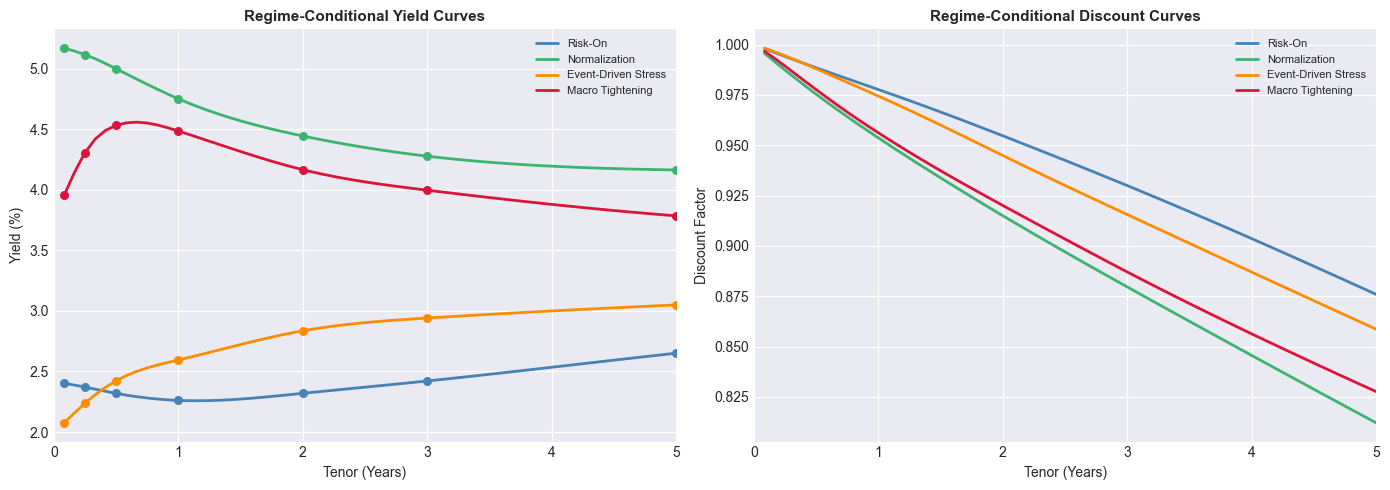

In [31]:
YIELD_TENORS_MO = np.array([1, 3, 6, 12, 24, 36, 60, 120])
YIELD_COLS = ['dgs1mo', 'dgs3mo', 'dgs6mo', 'dgs1', 'dgs2', 'dgs3', 'dgs5', 'dgs10']

# Monthly time steps for simulation
SIM_TENORS_MO = np.arange(1, 61)  # 1M to 60M

# Compute regime-conditional yield curves 
regime_yield_curves = {}
regime_discount_curves = {}

print("Regime-Conditional Yield Curves (%)")
print("="*70)
print(f"{'Tenor':<8}", end="")
for regime in REGIME_ORDER:
    print(f"{regime:>18}", end="")
print()
print("-"*70)

for regime in REGIME_ORDER:
    mask = df['regime_name'] == regime
    
    # Regime-conditional mean yields
    mean_yields = df.loc[mask, YIELD_COLS].mean()
    
    # Cubic spline interpolation
    cs = CubicSpline(
        YIELD_TENORS_MO,
        mean_yields.values,
        bc_type='natural'
    )
    
    # Interpolate at all monthly tenors
    yield_curve = cs(SIM_TENORS_MO)
    
    # Ensure non-negative yields
    yield_curve = np.maximum(yield_curve, 0.001)
    
    # Convert to decimal
    yield_curve_dec = yield_curve / 100
    
    # Compute discount factors
    # DF(t) = e^(-r(t) × t)
    # t in years = monthly tenor / 12
    t_years = SIM_TENORS_MO / 12
    discount_curve = np.exp(-yield_curve_dec * t_years)
    
    regime_yield_curves[regime] = yield_curve
    regime_discount_curves[regime] = discount_curve

# Print yield curve at key tenors
key_tenors = [1, 3, 6, 12, 24, 36, 60]
for t_mo in key_tenors:
    idx = t_mo - 1
    label = (f"{t_mo}M" if t_mo < 12 
             else f"{t_mo//12}Y")
    print(f"{label:<8}", end="")
    for regime in REGIME_ORDER:
        val = regime_yield_curves[regime][idx]
        print(f"{val:>17.4f}%", end="")
    print()

# Plot yield curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Yield curves
ax1 = axes[0]
for regime in REGIME_ORDER:
    ax1.plot(
        SIM_TENORS_MO / 12,
        regime_yield_curves[regime],
        color=REGIME_COLORS[regime],
        linewidth=2.0,
        label=regime
    )
    # Mark available data points
    plot_nodes_mo = YIELD_TENORS_MO[YIELD_TENORS_MO <= 60]

    ax1.scatter(
        plot_nodes_mo / 12,
        [regime_yield_curves[regime][t - 1] for t in plot_nodes_mo],
        color=REGIME_COLORS[regime],
        s=30,
        zorder=5
    )

ax1.set_title('Regime-Conditional Yield Curves',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Tenor (Years)')
ax1.set_ylabel('Yield (%)')
ax1.legend(fontsize=8)
ax1.set_xlim(0, 5)

# Plot 2: Discount curves
ax2 = axes[1]
for regime in REGIME_ORDER:
    ax2.plot(
        SIM_TENORS_MO / 12,
        regime_discount_curves[regime],
        color=REGIME_COLORS[regime],
        linewidth=2.0,
        label=regime
    )

ax2.set_title('Regime-Conditional Discount Curves', fontsize=11, fontweight='bold')
ax2.set_xlabel('Tenor (Years)')
ax2.set_ylabel('Discount Factor')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 5)

plt.tight_layout()
plt.savefig(
    '../data/processed/05_yield_discount_curves.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

Regime-conditional yield curves exhibit shapes consistent with the macroeconomic environments identified in Notebook 3.

The **Risk-On** curve is relatively flat and low (2.2–2.6%), reflecting the accommodative rate environment of 2021 and the post-rate-cut recovery period. The mild upward slope indicates broadly normal term premium conditions.

The **Normalization** curve is the highest in level (4.2–5.2%) and exhibits the most pronounced inversion, with short-end yields exceeding long-end yields by approximately 100 basis points. This reflects the restrictive policy environment of 2023–2024, where front-end rates remained elevated while long-end yields began pricing eventual rate cuts.

The **Event-Driven Stress** curve exhibits a mild upward slope (2.1–3.0%), consistent with the mixed rate environments associated with the short-lived stress episodes captured in this sample.

The **Macro Tightening** curve (3.8–4.6%) displays a front-end inversion before flattening at longer tenors, capturing the aggressive 2022 Fed hiking cycle during which short-end rates rose substantially faster than long-end yields.

Discount factors at the 5-year horizon range from approximately 0.815 (Normalization) to 0.876 (Risk-On), a difference of roughly 6 percentage points. This variation in discounting contributes to regime-dependent differences in CVA, alongside the regime effects on exposure profiles and implied default probabilities.

## Short Rate Model — Vasicek Calibration

As a baseline, we model the short rate using the Vasicek one-factor model:

$$dr(t) = \kappa(\theta - r(t))dt + \sigma dW(t)$$

where:
- $\kappa$ = mean reversion speed
- $\theta$ = constant long-run mean (regime mean)
- $\sigma$ = short rate volatility
- $W(t)$ = standard Brownian motion

Unlike Hull-White, the Vasicek model assumes a constant long-run mean $\theta$, which we set equal to the regime-conditional mean of the 1M Treasury yield.

### Calibration

Parameters $\kappa$ and $\sigma$ are estimated separately for each regime via OLS regression on the discretized SDE:

$$\Delta r_t = \kappa(\theta - r_t)\Delta t + \sigma\sqrt{\Delta t}\,\varepsilon_t, \quad \varepsilon_t \sim N(0,1)$$

Rearranging into regression form:

$$\Delta r_t = \underbrace{\kappa\theta\Delta t}_{a} + \underbrace{(-\kappa\Delta t)}_{b} \cdot r_t + \varepsilon_t$$

From the OLS estimates $\hat{a}$ and $\hat{b}$:

$$\hat{\kappa} = -\frac{\hat{b}}{\Delta t}, \quad 
\hat{\theta} = \frac{\hat{a}}{\hat{\kappa}\Delta t}, 
\quad \hat{\sigma} = \frac{\text{std}(\hat{\varepsilon})}
{\sqrt{\Delta t}}$$
This approach uses daily 1M Treasury yield observations within each regime, treating $\Delta t = 1/252$ (one trading day).

### Limitation

The constant $\theta$ assumption means the Vasicek model will not exactly reprice the observed yield curve. Simulated rate paths will converge to the regime mean rather than following the term structure of forward rates. This limitation is addressed later on, where we extend to the Hull-White model with a time-varying drift $\theta(t)$ calibrated to fit the initial yield curve exactly.

Vasicek Calibration Results
Regime                    kappa    sigma  theta(%)    Obs
-----------------------------------------------------------------
Risk-On                  1.8768 0.034298   3.6469%    393
Normalization            0.8462 0.007115   5.0225%    422
Event-Driven Stress      3.4273 0.050447   3.3269%    209
Macro Tightening         2.1768 0.019122   5.6209%    301


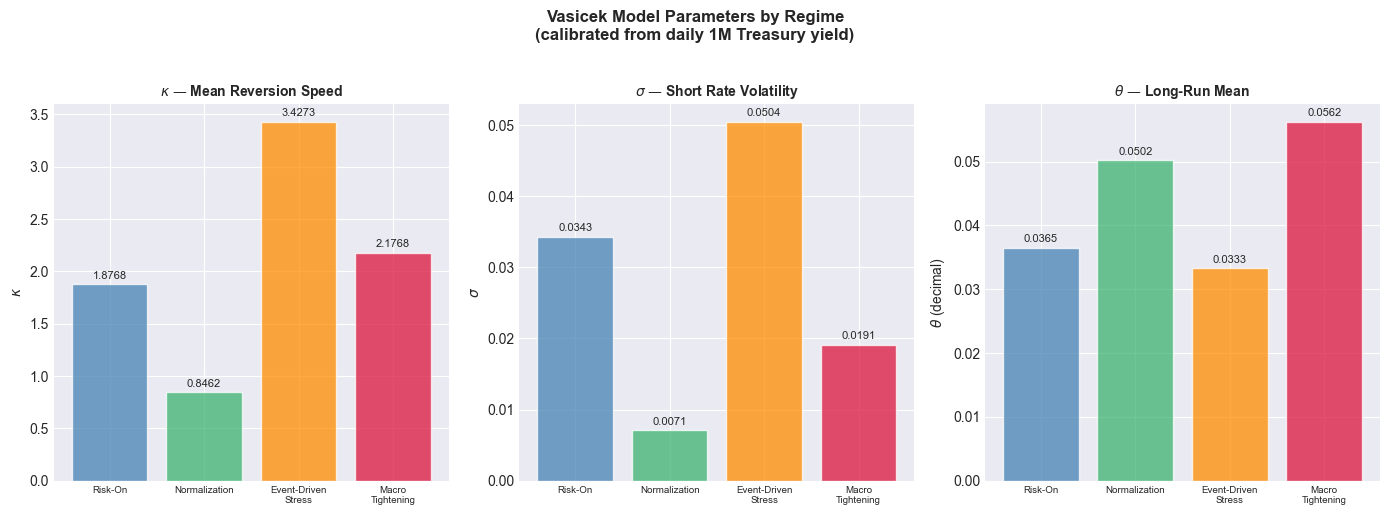

In [32]:
def calibrate_vasicek(r_series, dt=1/252):
    """
    Calibrate Vasicek parameters via OLS regression on discretized SDE:
    
    Parameters
    r_series : array-like, Short rate time series (decimal form)
    dt : float, Time step (default: 1/252 daily)
    
    Returns
    kappa : float, Mean reversion speed
    sigma : float, Short rate volatility  
    theta : float, Long-run mean (constant)
    """
    r     = np.array(r_series)
    dr    = np.diff(r)
    r_lag = r[:-1]

    # OLS regression: dr = a + b*r_lag + epsilon
    X = np.column_stack([np.ones(len(r_lag)), r_lag])
    coeffs = np.linalg.lstsq(X, dr, rcond=None)[0]
    a, b = coeffs

    # Recover structural parameters
    kappa  = max(-b / dt, 0.001)
    theta  = a / (kappa * dt)
    resid  = dr - (a + b * r_lag)
    sigma  = max(np.std(resid) / np.sqrt(dt), 0.0001)

    return kappa, sigma, theta

# Calibrate per regime
vasicek_params = {}

print("Vasicek Calibration Results")
print("="*65)
print(f"{'Regime':<22} {'kappa':>8} {'sigma':>8} "
      f"{'theta(%)':>9} {'Obs':>6}")
print("-"*65)

for regime in REGIME_ORDER:
    mask = df['regime_name'] == regime
    r_data = (df.loc[mask, 'dgs1mo'].dropna() / 100)

    kappa, sigma, theta = calibrate_vasicek(r_data, dt=1/252)
    vasicek_params[regime] = {
        'kappa': kappa,
        'sigma': sigma,
        'theta': theta,
    }

    print(f"{regime:<22} {kappa:>8.4f} "
          f"{sigma:>8.6f} {theta*100:>8.4f}% "
          f"{mask.sum():>6}")

# Visualize parameters 
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

param_config = [
    ('kappa', '$\\kappa$ — Mean Reversion Speed',  '$\\kappa$'),
    ('sigma', '$\\sigma$ — Short Rate Volatility', '$\\sigma$'),
    ('theta', '$\\theta$ — Long-Run Mean', '$\\theta$ (decimal)'),
]

for ax, (param, title, ylabel) in zip(
    axes, param_config
):
    values = [vasicek_params[r][param] for r in REGIME_ORDER]
    colors = [REGIME_COLORS[r] for r in REGIME_ORDER]

    bars = ax.bar(
        range(len(REGIME_ORDER)),
        values,
        color=colors,
        alpha=0.75,
        edgecolor='white'
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values)*0.01,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=8
        )

    ax.set_title(title, fontsize=10,
                 fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(REGIME_ORDER)))
    ax.set_xticklabels(
        [r.replace(' ', '\n')
         for r in REGIME_ORDER],
        fontsize=7
    )

plt.suptitle(
    'Vasicek Model Parameters by Regime\n'
    '(calibrated from daily 1M Treasury yield)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/05_vasicek_calibration.png',dpi=150, bbox_inches='tight')
plt.show()

Calibrated Vasicek parameters vary meaningfully across regimes, confirming that short-rate dynamics are regime-dependent. Mean reversion speed $\kappa$ is highest in Event-Driven Stress (3.43), indicating rapid reversion following short-lived rate shocks, while Normalization exhibits the lowest $\kappa$ (0.85), consistent with the persistent and stable rate environment of 2023–2024. Short-rate volatility $\sigma$ is also highest in Event-Driven Stress (0.0504) and lowest in Normalization (0.0071), reflecting the contrast between abrupt stress episodes and calm post-tightening conditions. Long-run mean $\theta$ follows the expected rate-level ordering, highest in Macro Tightening (5.62%) and Normalization (5.02%), and lower in Risk-On (3.65%) and Event-Driven Stress (3.33%). Overall, the parameter estimates are economically consistent with the HMM regime interpretation established in Notebook 3 and provide distinct short-rate dynamics for the regime-conditional IRS exposure simulation.

## Hull-White Extension — Time-Varying Drift

The Vasicek model assumes a constant long-run mean $\theta$, which may cause simulated short-rate paths to deviate from the observed term structure. To incorporate the regime-conditional yield curve constructed before, we extend the framework to the Hull-White one-factor model with a time-varying drift term $\theta(t)$:

$$dr(t) = \kappa(\theta(t) - r(t))dt + \sigma dW(t)$$

### Determination of θ(t)

Given the regime-conditional zero-rate curve $r(0,t)$, the instantaneous forward rate is approximated by (assuming continuously compounded zero rates):

$$f(0,t) = -\frac{\partial \ln P(0,t)}{\partial t} = r(0,t) + t \cdot \frac{\partial r(0,t)}{\partial t}$$

The Hull-White drift function that fits this forward curve exactly is:

$$\theta(t) = \frac{1}{\kappa}\frac{\partial f(0,t)}{\partial t} + f(0,t) + 
\frac{\sigma^2}{2\kappa^2}\left(1 - e^{-2\kappa t}\right)$$

We retain the regime-specific $\kappa$ and $\sigma$ from the Vasicek calibration, and compute $\theta(t)$ numerically from the interpolated regime-conditional yield curves. This extension allows the simulated short-rate dynamics to better reflect the prevailing market term structure while preserving the historical mean-reversion and volatility characteristics estimated from the data.

Hull-White theta(t) at Key Tenors (%)
Tenor            Risk-On   NormalizationEvent-Driven StressMacro Tightening
-----------------------------------------------------------------
1M              2.2699%        4.6897%        2.5135%        5.1487%
6M              2.1048%        3.4643%        2.8607%        4.3850%
1Y              2.3506%        3.6558%        2.9983%        3.7686%
2Y              2.6479%        3.7608%        3.1950%        3.6427%
3Y              2.8981%        3.9418%        3.1650%        3.5362%
4Y              3.1514%        4.1190%        3.2464%        3.3958%
5Y              3.2641%        4.1131%        3.3012%        3.3889%


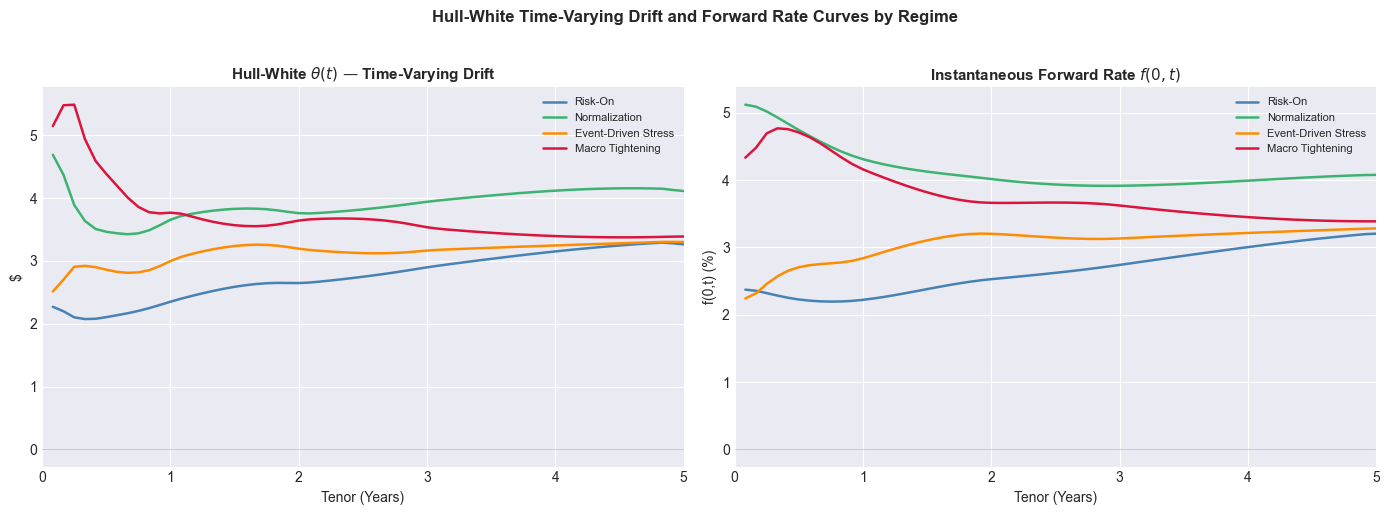

In [37]:
def compute_hw_theta(kappa, sigma, yield_curve_pct, sim_tenors_mo):
    """
    Compute Hull-White time-varying drift from the initial yield curve.

    Parameters
    kappa : float, Mean reversion speed (from Vasicek)
    sigma : float, Short rate volatility (from Vasicek)
    yield_curve_pct : array, Zero rates in % at monthly tenors
    sim_tenors_mo : array, Monthly tenor nodes (1 to 60)
    
    Returns
    theta_t : array, Time-varying drift at each monthly tenor
    f_t : array, Instantaneous forward rates
    """
    # Convert yields to decimal
    r = yield_curve_pct / 100

    # Time in years
    t = sim_tenors_mo / 12

    # Zero-coupon bond prices
    P = np.exp(-r * t)

    # Instantaneous forward rates f(0,t) = -d(ln P)/dt
    # Numerical differentiation using central diff
    dt_years = 1/12
    ln_P = np.log(P)

    f = np.zeros(len(t))
    f[0] = -(ln_P[1] - ln_P[0]) / dt_years
    f[-1] = -(ln_P[-1] - ln_P[-2]) / dt_years
    f[1:-1] = -(ln_P[2:] - ln_P[:-2]) / (2 * dt_years)

    # Derivative of forward rates df/dt
    df_dt = np.zeros(len(t))
    df_dt[0] = (f[1] - f[0]) / dt_years
    df_dt[-1] = (f[-1] - f[-2]) / dt_years
    df_dt[1:-1] = (f[2:] - f[:-2]) / (2 * dt_years)

    # Hull-White theta(t)
    convexity = (sigma**2 / (2 * kappa**2)) * (1 - np.exp(-2 * kappa * t))
    theta_t = (1/kappa) * df_dt + f + convexity

    return theta_t, f

# Compute HW theta for each regime 
hw_params = {}

print("Hull-White theta(t) at Key Tenors (%)")
print("="*65)
print(f"{'Tenor':<8}", end="")
for regime in REGIME_ORDER:
    print(f"{regime:>16}", end="")
print()
print("-"*65)

for regime in REGIME_ORDER:
    kappa = vasicek_params[regime]['kappa']
    sigma = vasicek_params[regime]['sigma']
    yc    = regime_yield_curves[regime]

    theta_t, f_t = compute_hw_theta(
        kappa, sigma, yc, SIM_TENORS_MO
    )

    hw_params[regime] = {
        'kappa':   kappa,
        'sigma':   sigma,
        'theta_t': theta_t,
        'f_t':     f_t,
    }

# Print theta at key tenors
key_tenors_mo = [1, 6, 12, 24, 36, 48, 60]
labels_map    = {
    1: '1M', 6: '6M', 12: '1Y',
    24: '2Y', 36: '3Y', 48: '4Y', 60: '5Y'
}

for t_mo in key_tenors_mo:
    idx   = t_mo - 1
    label = labels_map[t_mo]
    print(f"{label:<8}", end="")
    for regime in REGIME_ORDER:
        val = hw_params[regime]['theta_t'][idx]*100
        print(f"{val:>14.4f}%", end="")
    print()

# Plot theta(t) and f(0,t)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for regime in REGIME_ORDER:
    t_years = SIM_TENORS_MO / 12
    color   = REGIME_COLORS[regime]

    # Plot theta(t)
    axes[0].plot(
        t_years,
        hw_params[regime]['theta_t'] * 100,
        color=color, linewidth=1.8,
        label=regime
    )

    # Plot forward curve f(0,t)
    axes[1].plot(
        t_years,
        hw_params[regime]['f_t'] * 100,
        color=color, linewidth=1.8,
        label=regime
    )

for ax, title, ylabel in zip(
    axes,
    ['Hull-White $\\theta(t)$ — Time-Varying Drift',
     'Instantaneous Forward Rate $f(0,t)$'],
    ['$', 'f(0,t) (%)']
):
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Tenor (Years)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 5)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.3)

plt.suptitle(
    'Hull-White Time-Varying Drift and '
    'Forward Rate Curves by Regime',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/05_hw_theta.png', dpi=150, bbox_inches='tight')
plt.show()

The Hull-White forward-rate and drift functions exhibit clear regime dependence and broadly inherit the shapes of the regime-conditional yield curves constructed before. 

**Forward rate curves $f(0,t)$** follow the same ordering as the zero-rate curves: Normalization and Macro Tightening dominate at the short end, while Risk-On and Event-Driven Stress remain at lower levels throughout the horizon. The inverted shape of the Normalization and Macro Tightening forward curves — declining from short to medium maturities before stabilizing — is consistent with the inverted yield curves observed during these regimes, reflecting market expectations of eventual rate cuts embedded in the term structure.

**$\theta(t)$ exhibits mild short-end oscillations** for Normalization and Macro Tightening, particularly in the 0–1 year region. These arise from numerical differentiation of the interpolated yield curves when computing forward-rate derivatives. Since the Hull-White drift depends on both the forward curve and its slope, small interpolation irregularities at the short end can generate localized spikes in $\theta(t)$. This is a numerical artifact rather than a meaningful economic signal.

At longer maturities (2–5 years), $\theta(t)$ stabilizes and converges across regimes toward approximately 3.3–4.3%, consistent with the medium- and long-term rate levels implied by the regime yield curves. The convergence primarily reflects the flattening of the forward curves at longer maturities, which reduces the contribution of the derivative term in the Hull-White drift specification.

The Hull-White parameters are summarized as:
| Regime               | $\kappa$ | $\sigma$ | Initial $r_0$ |
|----------------------|----------|--------|------------|
| Risk-On              | 1.877 | 0.0343 | 2.40%      |
| Normalization        | 0.846 | 0.0071 | 5.17%      |
| Event-Driven Stress  | 3.427 | 0.0504 | 2.08%      |
| Macro Tightening     | 2.177 | 0.0191 | 3.96%      |

where $\kappa$ and $\sigma$ are inherited from the Vasicek calibration, and the initial short rate $r_0$ is the regime-conditional mean 1M Treasury yield.

## Monte Carlo Simulation of Rate Paths

We simulate short rate paths under both the Vasicek and Hull-White models using the Euler-Maruyama discretization scheme:

**Vasicek:**
$$r_{t+\Delta t} = r_t + \kappa(\theta - r_t)\Delta t + \sigma\sqrt{\Delta t}\,\varepsilon_t$$

**Hull-White:**
$$r_{t+\Delta t} = r_t + \kappa(\theta(t) - r_t)\Delta t + \sigma\sqrt{\Delta t}\,\varepsilon_t$$

where $\varepsilon_t \sim N(0,1)$ and $\Delta t = 1/12$ (monthly steps).

For each regime, we simulate $N = 1000$ paths over 60 monthly steps (5 years), using the regime-specific calibrated parameters. The initial short rate $r_0$ is set to the regime-conditional mean 1M Treasury yield.

Parameters are estimated from daily Treasury yield observations but simulated on a monthly grid for computational efficiency and consistency with the exposure horizon.

The simulated rate paths will feed directly into the IRS mark-to-market valuation in subsequent CVA analysis, where each path produces a swap value at each time step, from which the expected exposure profile is derived.

Simulating rate paths
  Paths: 1,000 | Steps: 60 | dt: 0.0833

Risk-On:
  r0 = 2.4033%
  Vasicek  mean r(5Y) = 3.7210%
  HW       mean r(5Y) = 3.0885%

Normalization:
  r0 = 5.1692%
  Vasicek  mean r(5Y) = 5.0418%
  HW       mean r(5Y) = 4.0725%

Event-Driven Stress:
  r0 = 2.0761%
  Vasicek  mean r(5Y) = 3.1888%
  HW       mean r(5Y) = 3.2619%

Macro Tightening:
  r0 = 3.9552%
  Vasicek  mean r(5Y) = 5.6172%
  HW       mean r(5Y) = 3.3552%



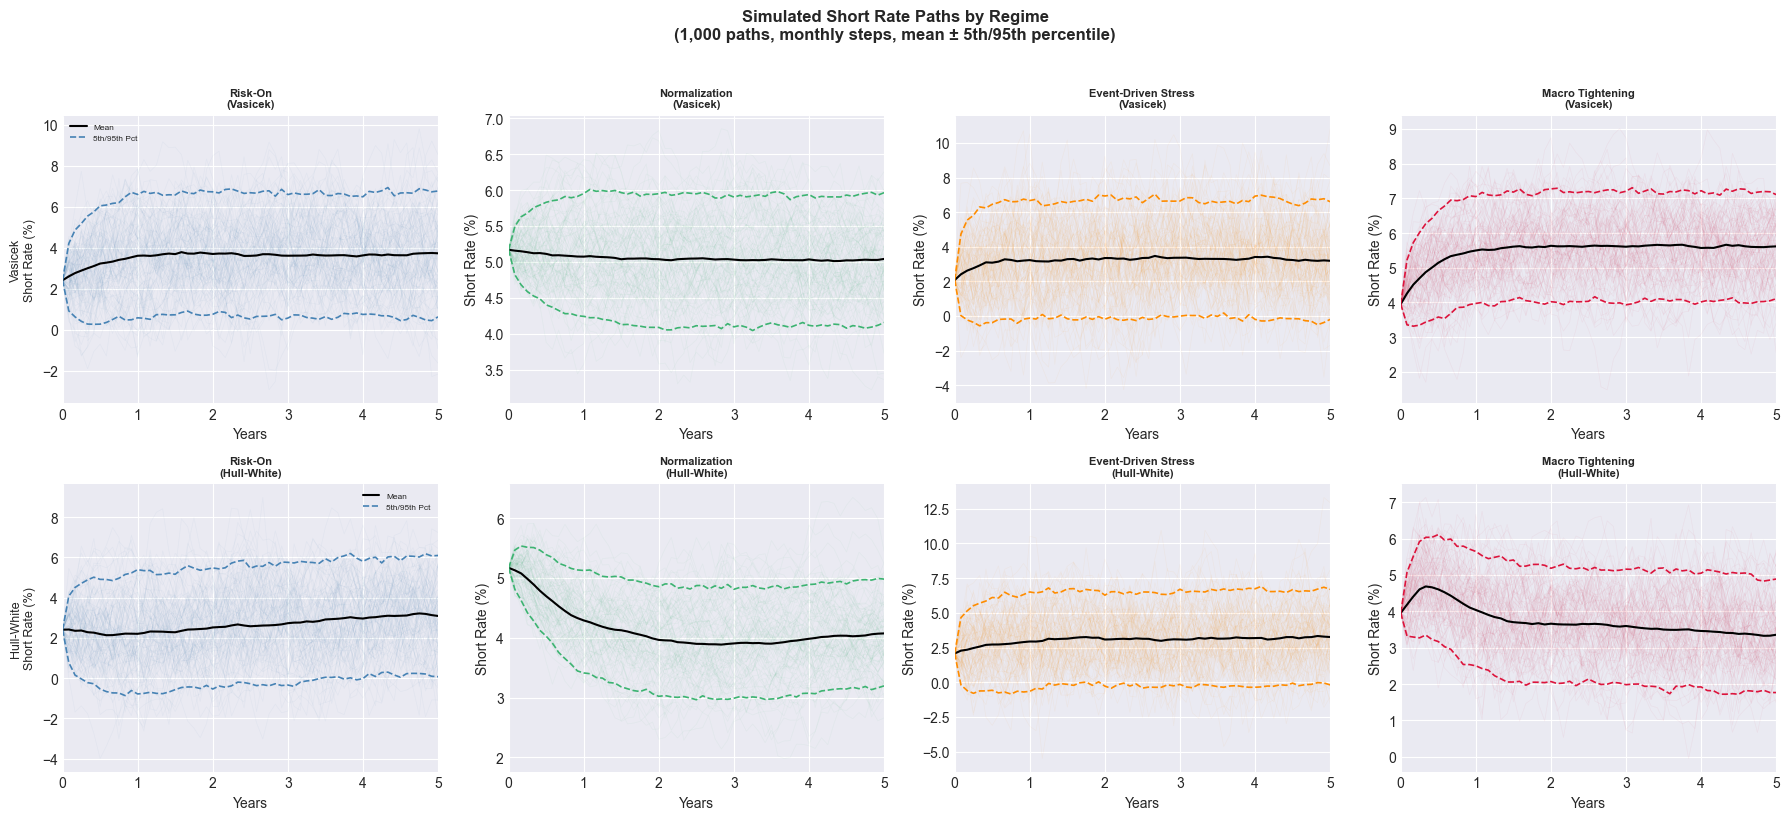

In [38]:
def simulate_vasicek(kappa, sigma, theta, r0, n_paths, n_steps, dt):
    """
    Simulate short rate paths under Vasicek model. Euler-Maruyama discretization.
    
    Returns
    paths : array (n_paths, n_steps+1), Simulated short rate paths
    """
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0

    for t in range(n_steps):
        eps = np.random.randn(n_paths)
        drift = kappa * (theta - paths[:, t]) * dt
        diffusion = sigma * np.sqrt(dt) * eps
        paths[:, t+1] = paths[:, t] + drift + diffusion

    return paths

def simulate_hull_white(kappa, sigma, theta_t, r0, n_paths, n_steps, dt):
    """
    Simulate short rate paths under Hull-White model. Uses time-varying theta_t array.
    
    Returns
    paths: array (n_paths, n_steps+1), Simulated short rate paths
    """
    paths = np.zeros((n_paths, n_steps + 1))
    paths[:, 0] = r0

    for t in range(n_steps):
        eps = np.random.randn(n_paths)
        drift = kappa * (
            theta_t[t] - paths[:, t]
        ) * dt
        diffusion = sigma * np.sqrt(dt) * eps
        paths[:, t+1] = (
            paths[:, t] + drift + diffusion
        )

    return paths

# Simulation parameters
N_PATHS = 1000
N_STEPS = 60  # Monthly steps
DT = 1/12  # Monthly time step

np.random.seed(926)

vasicek_paths = {}
hw_paths = {}

print("Simulating rate paths")
print(f"  Paths: {N_PATHS:,} | Steps: {N_STEPS} "
      f"| dt: {DT:.4f}")
print()

for regime in REGIME_ORDER:
    kappa = vasicek_params[regime]['kappa']
    sigma = vasicek_params[regime]['sigma']
    theta = vasicek_params[regime]['theta']
    theta_t = hw_params[regime]['theta_t']
    r0 = df.loc[
        df['regime_name'] == regime, 'dgs1mo'
    ].mean() / 100

    # Vasicek simulation
    vasicek_paths[regime] = simulate_vasicek(
        kappa, sigma, theta,
        r0, N_PATHS, N_STEPS, DT
    )

    # Hull-White simulation
    hw_paths[regime] = simulate_hull_white(
        kappa, sigma, theta_t,
        r0, N_PATHS, N_STEPS, DT
    )

    v_mean = vasicek_paths[regime].mean(axis=0)
    h_mean = hw_paths[regime].mean(axis=0)

    print(f"{regime}:")
    print(f"  r0 = {r0*100:.4f}%")
    print(f"  Vasicek  mean r(5Y) = "
          f"{v_mean[-1]*100:.4f}%")
    print(f"  HW       mean r(5Y) = "
          f"{h_mean[-1]*100:.4f}%")
    print()

# Visualization
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
time_mo   = np.arange(N_STEPS + 1) / 12

for col, regime in enumerate(REGIME_ORDER):
    color = REGIME_COLORS[regime]

    for row, (paths, model_name) in enumerate([
        (vasicek_paths[regime], 'Vasicek'),
        (hw_paths[regime], 'Hull-White'),
    ]):
        ax = axes[row, col]

        # Plot sample paths (first 100)
        for i in range(100):
            ax.plot(
                time_mo, paths[i] * 100,
                color=color, alpha=0.05,
                linewidth=0.5
            )

        # Plot mean path
        ax.plot(
            time_mo,
            paths.mean(axis=0) * 100,
            color='black', linewidth=1.5,
            label='Mean'
        )

        # Plot 5th and 95th percentile
        ax.plot(
            time_mo,
            np.percentile(paths, 5, axis=0) * 100,
            color=color, linewidth=1.2,
            linestyle='--', label='5th/95th Pct'
        )
        ax.plot(
            time_mo,
            np.percentile(paths, 95, axis=0) * 100,
            color=color, linewidth=1.2,
            linestyle='--'
        )

        ax.set_title(
            f'{regime}\n({model_name})',
            fontsize=8, fontweight='bold'
        )
        ax.set_xlabel('Years')
        ax.set_ylabel('Short Rate (%)')
        ax.set_xlim(0, 5)

        if col == 0:
            ax.legend(fontsize=6)

# Row labels
for row, label in enumerate(
    ['Vasicek', 'Hull-White']
):
    axes[row, 0].set_ylabel(
        f'{label}\nShort Rate (%)',
        fontsize=9
    )

plt.suptitle(
    f'Simulated Short Rate Paths by Regime\n'
    f'({N_PATHS:,} paths, monthly steps, '
    f'mean ± 5th/95th percentile)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../data/processed/05_rate_paths.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

Simulated rate paths are consistent with the calibrated model parameters and the economic characteristics of each regime.

**Vasicek paths** exhibit classic mean reversion toward the constant long-run mean \(\theta\). Risk-On paths rise gradually from \(r_0 = 2.40\%\) toward \(\theta = 3.65\%\), while Macro Tightening paths rise from \(r_0 = 3.96\%\) toward \(\theta = 5.62\%\). The width of the simulation bands reflects regime-specific volatility: Event-Driven Stress produces the widest dispersion ($\sigma = 0.0504$), while Normalization produces the narrowest ($\sigma = 0.0071$).

**Hull-White paths** follow the regime-implied forward curve rather than a constant mean, producing economically distinct behavior. This difference is most visible in Normalization and Macro Tightening, where inverted yield curves cause the Hull-White mean path to decline from its initial level before stabilizing. Normalization falls from 5.17% to 4.07% at 5 years, while Macro Tightening falls from 3.96% to 3.36%.

The divergence between Vasicek and Hull-White is largest in Macro Tightening, where the 5-year mean rate differs by approximately 226 bps (5.62% vs 3.36%). This reflects the inverted yield curve embedded in the Macro Tightening regime, which Hull-White incorporates through its time-varying drift while Vasicek ignores through constant-mean reversion.

Negative rates appear in the lower tail of Risk-On and Event-Driven Stress simulations under both models. This is a known limitation of Gaussian short-rate models and is acceptable for this stylized exposure simulation. Models with non-negative rate constraints, such as CIR, would eliminate this issue at the cost of additional calibration complexity.

Given its consistency with the regime-conditional yield curves, the Hull-White model is used as the primary input for IRS valuation and exposure calculation in the following analysis. Vasicek paths are retained as a baseline comparison.

## Interest Rate Swap (IRS) Valuation and Exposure Profile

### IRS Contract Specification

We consider a 5-year fixed-for-floating interest rate swap with the following terms:

- **Notional Principal**: \$100 million
- **Tenor**: 5 years (60 monthly steps)
- **Fixed rate payer**: us (the bank)
- **Floating rate receiver**: us (the bank)
- **Fixed rate**: set at-the-money (ATM) at inception, equal to the par swap rate under each regime's initial yield curve
- **Floating rate**: 1M short rate $r_t$
- **Payment frequency**: monthly

From our perspective as the fixed rate payer, the swap has positive value when rates rise (floating receipts exceed fixed payments) and negative value when rates fall.

### IRS Mark-to-Market Valuation

At each time step $t$ along a simulated path, the remaining swap value is the present value of remaining floating cash flows minus the present value of remaining fixed cash flows:

$$V(t) = \sum_{s=t+1}^{T} DF_t(s) \cdot (r_s - K) \cdot \Delta t \cdot N$$

where:
- $K$ = fixed rate (par swap rate at inception)
- $r_s$ = floating rate at time $s$
- $DF_t(s)$ = discount factor from $t$ to $s$, computed from the simulated short rate path
- $\Delta t = 1/12$ (monthly)
- $N$ = notional

In practice we approximate $V(t)$ using the simulated short rate path to construct path-consistent discount factors.

### Expected Exposure

From the 1,000 simulated paths, we compute at each monthly time step:

$$EPE(t) = \mathbb{E}[\max(V(t), 0)]$$
$$ENE(t) = \mathbb{E}[\min(V(t), 0)]$$

The **Expected Positive Exposure (EPE)** profile captures our exposure to counterparty default, while the **Expected Negative Exposure (ENE)** profile captures the counterparty's exposure to our default.

IRS Valuation
Regime                   Par Rate     Peak EPE     Peak Tenor       Min ENE
---------------------------------------------------------------------------
Risk-On                   2.6415%       1.428M       1.58Y       -1.453M
Normalization             4.1852%       0.479M       0.08Y       -0.965M
Event-Driven Stress       3.0439%       1.276M       0.67Y       -1.202M
Macro Tightening          3.8104%       0.546M       0.08Y       -1.187M


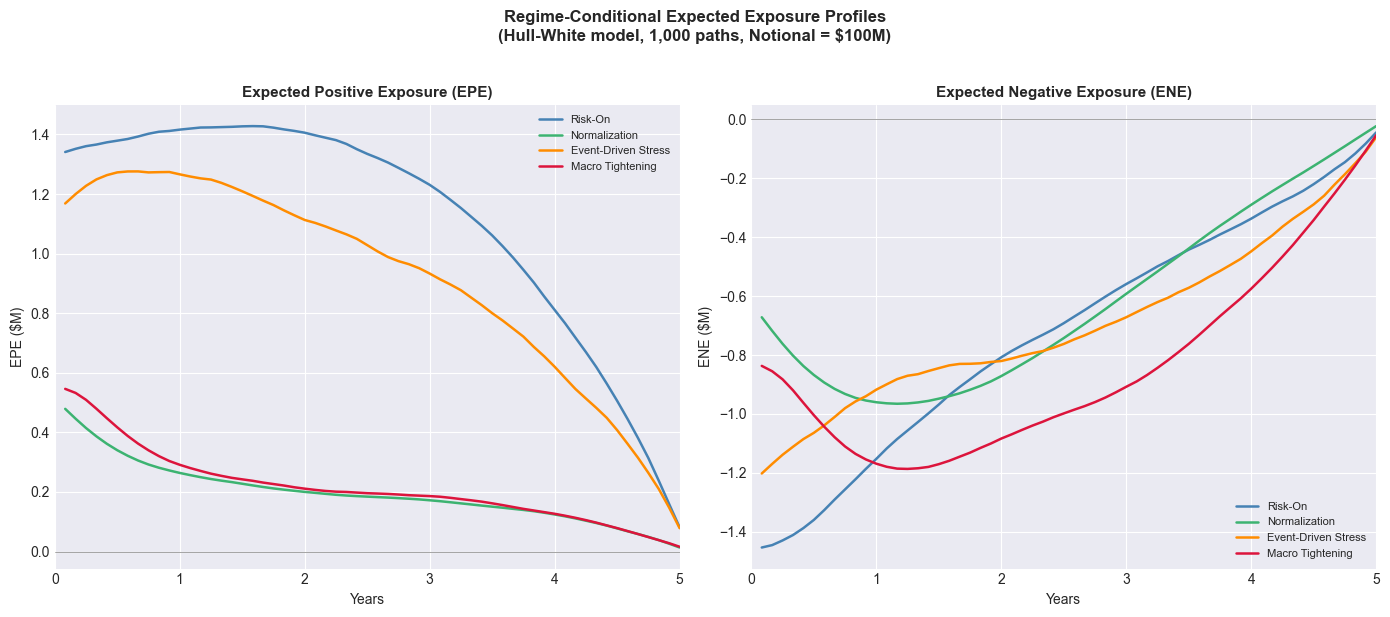

In [ ]:
def compute_par_swap_rate(yield_curve_dec, dt=1/12, n_steps=60):
    """
    Compute par swap rate from yield curve.
    Par rate K such that PV(fixed) = PV(floating).
    
    Parameters
    ----------
    yield_curve_dec : array, Zero rates in decimal at monthly tenors
    dt : float, Time step
    n_steps : int, Number of steps
    
    Returns
    -------
    K : float, Par swap rate
    """
    t_years = np.arange(1, n_steps+1) / 12
    DF = np.exp(-yield_curve_dec * t_years)

    K = (1 - DF[-1]) / (np.sum(DF) * dt)
    return K

def compute_irs_value(paths, K, dt=1/12):
    """
    Compute IRS mark-to-market value at each time step for all paths.
    
    Parameters
    ----------
    paths : array (n_paths, n_steps+1), Simulated short rate paths (decimal)
    K : float, Fixed rate
    dt : float, Time step

    Returns
    -------
    values : array (n_paths, n_steps), IRS value at each time step
    """
    n_paths, n_steps_1 = paths.shape
    n_steps = n_steps_1 - 1
    values  = np.zeros((n_paths, n_steps))

    for t in range(n_steps):
        # Remaining steps from t+1 to T
        remaining = paths[:, t+1:]
        n_rem     = remaining.shape[1]

        if n_rem == 0:
            continue

        # Path-consistent discount factors
        cum_rates = np.cumsum(
            remaining * dt, axis=1
        )
        df_path = np.exp(-cum_rates)

        # PV of net cash flows
        net_cf = (remaining - K) * dt * NOTIONAL
        values[:, t] = np.sum(
            df_path * net_cf, axis=1
        )

    return values

# Compute regime-specific par rates and IRS values 
par_rates = {}
irs_values_hw = {}  # Hull-White
epe_profiles = {}  # Expected Positive Exposure
ene_profiles = {}  # Expected Negative Exposure

print("IRS Valuation")
print("="*75)
print(f"{'Regime':<22} {'Par Rate':>10} "
      f"{'Peak EPE':>12} {'Peak Tenor':>14} {'Min ENE':>13}")
print("-"*75)

for regime in REGIME_ORDER:
    # Regime-specific ATM par swap rate
    yc_dec = np.maximum(
        regime_yield_curves[regime] / 100, 0.001
    )
    K = compute_par_swap_rate(yc_dec)
    par_rates[regime] = K

    # IRS values under HW
    v_hw = compute_irs_value(
        hw_paths[regime], K
    )
    irs_values_hw[regime] = v_hw

    # EPE and ENE profiles
    epe  = np.mean(np.maximum(v_hw, 0), axis=0)
    ene = np.mean(np.minimum(v_hw, 0), axis=0)

    epe_profiles[regime]  = epe
    ene_profiles[regime] = ene

    print(f"{regime:<22} {K*100:>9.4f}% "
          f"{epe.max()/1e6:>11.3f}M "
          f"{time_mo[epe.argmax()]:>10.2f}Y "
          f"{ene.min()/1e6:>12.3f}M")

# Plot EPE and ENE profiles
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
time_mo   = np.arange(1, N_STEPS+1) / 12

for regime in REGIME_ORDER:
    color = REGIME_COLORS[regime]

    axes[0].plot(
        time_mo,
        epe_profiles[regime] / 1e6,
        color=color, linewidth=1.8,
        label=regime
    )
    axes[1].plot(
        time_mo,
        ene_profiles[regime] / 1e6,
        color=color, linewidth=1.8,
        label=regime
    )

for ax, title, ylabel in zip(
    axes,
    ['Expected Positive Exposure (EPE)',
     'Expected Negative Exposure (ENE)'],
    ['EPE ($M)', 'ENE ($M)']
):
    ax.set_title(title, fontsize=11,
                 fontweight='bold')
    ax.set_xlabel('Years')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.axhline(y=0, color='black',
               linewidth=0.5, alpha=0.5)
    ax.set_xlim(0, 5)

plt.suptitle(
    'Regime-Conditional Expected Exposure Profiles\n'
    f'(Hull-White model, {N_PATHS:,} paths, '
    f'Notional = $100M)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    '../data/processed/05_exposure_profiles.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

The regime-conditional IRS exposure profiles exhibit economically meaningful differences across market environments and are consistent with the yield curve structures and Hull-White dynamics established earlier in the analysis.

The regime-specific ATM par swap rates align closely with the macroeconomic interpretation of each HMM regime:

- **Risk-On:** 2.64%
- **Event-Driven Stress:** 3.04%
- **Macro Tightening:** 3.81%
- **Normalization:** 4.19%

Risk-On and Event-Driven Stress correspond to lower-rate environments, while Macro Tightening and Normalization reflect the elevated rate regimes observed during the 2022–2024 hiking cycle. The ordering of par rates is therefore fully consistent with the regime-dependent Treasury yield curves constructed before.

The **timing and shape of the EPE profiles** vary substantially across regimes. For Normalization and Macro Tightening, peak EPE occurs almost immediately after inception (approximately 0.08Y, or one month), after which exposure declines monotonically. This behavior is not a numerical artifact. Rather, it reflects the inverted yield curves embedded in these regimes, which cause the Hull-White forward rate dynamics to drift downward over time. As a result, the pay-fixed IRS becomes progressively less favorable after inception, causing positive exposure to decay rapidly. 

By contrast, Risk-On and Event-Driven Stress display the more typical hump-shaped exposure profile commonly observed for ATM swaps under upward-sloping or mildly normal yield curves. Peak EPE occurs later in the life of the swap (Risk-On: peak at 1.58Y， Event-Driven Stress: peak at 0.67Y). Under these regimes, future floating rates are not expected to decline systematically, allowing exposure to build gradually before amortizing toward maturity.

The **magnitudes of EPE and ENE** are not perfectly symmetric across regimes, particularly under inverted yield curve environments. For Risk-On, the profile is nearly symmetric (Peak EPE = \$1.43M, Minimum ENE = -\$1.45M). This is consistent with a relatively balanced distribution of future rate outcomes around the ATM fixed rate. However, in Normalization, ENE materially exceeds EPE in magnitude (Peak EPE = \$0.48M, Minimum ENE = -\$0.97M). This asymmetry reflects the downward drift embedded in the Hull-White forward curve under inverted yield curve conditions. Since future short rates are expected to decline over time, the pay-fixed swap becomes out-of-the-money more frequently than in normal curve environments, increasing negative exposure relative to positive exposure.

Overall, the exposure profiles confirm that regime-dependent yield curve shape and short-rate dynamics materially affect both the magnitude and timing of counterparty exposure. In particular, inverted yield curve regimes compress positive exposure and shift peak exposure toward the front end of the swap, while normal curve environments generate larger and more persistent positive exposure profiles.

These regime-dependent exposure dynamics will directly affect CVA, DVA, and BCVA in the following sections when combined with the regime-conditional default probability term structures calibrated in Notebook 4.

## UCVA, UDVA and BCVA Computation

We compute three credit valuation adjustments using the regime-conditional exposure profiles and the implied PD term structures.

### UCVA (Unilateral CVA)

The cost to us of counterparty default risk, assuming we are default-free:

$$UCVA = -LGD_C \sum_{t=1}^{T} DF(t) \cdot EPE(t) \cdot q_C(t-1, t)$$

where $q_C(t-1,t) = S_C(t-1) - S_C(t)$ is the survival-adjusted marginal PD of the counterparty.

### UDVA (Unilateral DVA)

The benefit to us of our own default risk:

$$UDVA = -LGD_B \sum_{t=1}^{T} DF(t) \cdot ENE(t) \cdot q_B(t-1, t)$$

where $q_B(t-1,t) = S_B(t-1) - S_B(t)$ is the survival-adjusted marginal PD of our own entity.

### BCVA (Bilateral CVA)

Accounts for first-to-default risk by weighting each party's exposure with the other party's survival probability:

$$BCVA = -LGD_C \sum_{t=1}^{T} DF(t) \cdot EPE(t) \cdot q_C(t-1,t) \cdot S_B(t)$$
$$- LGD_B \sum_{t=1}^{T} DF(t) \cdot ENE(t) \cdot q_B(t-1,t) \cdot S_C(t)$$


### Marginal PD Construction

Regime-conditional hazard rates $\lambda$ calibrated in Notebook 4 are used directly to generate monthly marginal PDs:

$$S(t) = e^{-\lambda t}$$

$$q(t-1, t) = S(t-1) - S(t) = e^{-\lambda(t-1/12)} - e^{-\lambda t}$$

where $t$ is expressed in years and steps are monthly ($\Delta t = 1/12$). Under the constant hazard rate assumption, this formula holds exactly at any frequency without requiring interpolation.

**Discount factors**: we use the regime-conditional initial yield curve discount factors, consistent with the swap valuation.

**Counterparty**: BBB-rated (lowest IG)  
**Own entity**: IG-rated (well-capitalized bank)

XVA Results
  Counterparty: BBB | Own: IG | LGD: 60%

Regime                     UCVA ($)     UDVA ($)     BCVA ($) Net XVA ($, no survival adj)
---------------------------------------------------------------------------
Risk-On                  -54,572.11    28,560.45   -25,286.28    -26,011.66
Normalization            -10,616.12    27,132.51    15,831.86     16,516.39
Event-Driven Stress      -58,591.60    36,105.89   -21,910.65    -22,485.71
Macro Tightening         -17,011.92    53,106.53    33,722.60     36,094.61


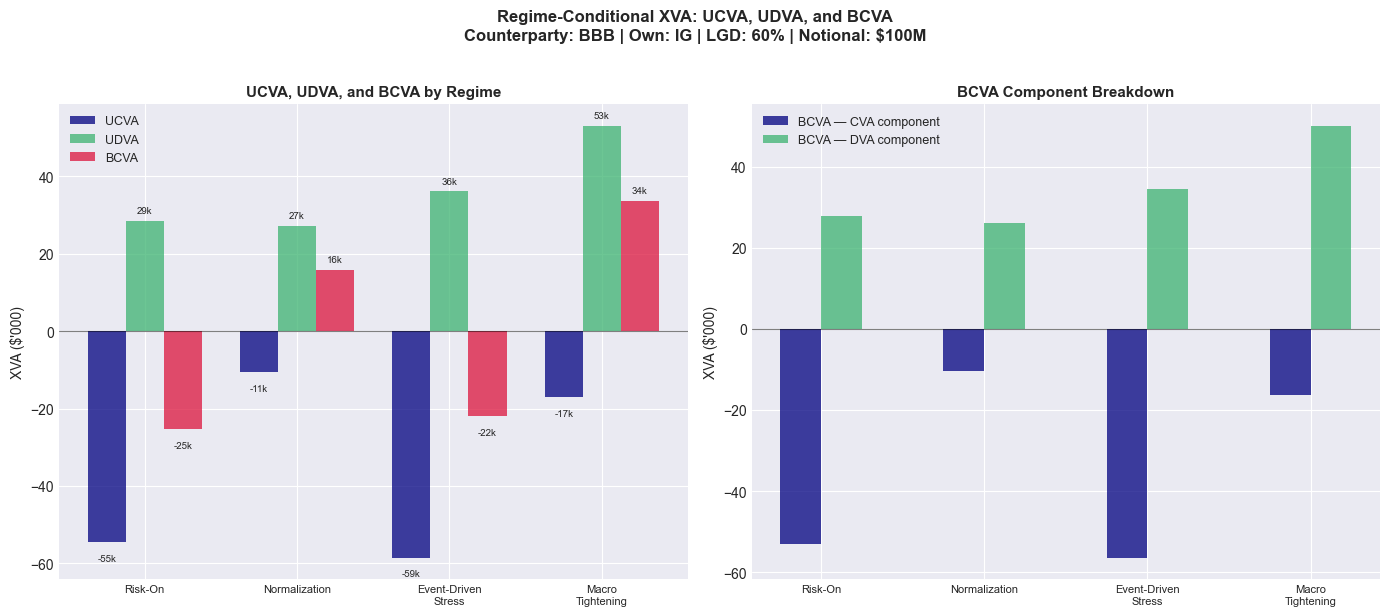

In [64]:
def compute_xva(epe_profile, ene_profile, df_curve, lam_cp, lam_own, lgd=0.60, dt=1/12):
    """
    Compute UCVA, UDVA, and BCVA.
    
    Parameters
    ----------
    epe_profile: array (n_steps,), Expected Positive Exposure at each, monthly step
    ene_profile: array (n_steps,), Expected Negative Exposure at each, monthly step
    df_curve: array (n_steps,), Discount factors at each monthly step
    lam_cp: float, Counterparty hazard rate (BBB)
    lam_own: float, Own hazard rate (IG)
    lgd: float, Loss Given Default
    dt: float, Time step (monthly = 1/12)
    
    Returns
    -------
    ucva, udva, bcva : float, XVA metrics in dollars
    """
    n_steps = len(epe_profile)
    t_mo    = np.arange(1, n_steps+1) * dt

    # Survival rates at each monthly step
    S_cp  = np.exp(-lam_cp  * t_mo)
    S_own = np.exp(-lam_own * t_mo)

    # Marginal PDs (survival-adjusted)
    # q(t-1,t) = S(t-1) - S(t)
    S_cp_lag  = np.concatenate([[1.0], S_cp[:-1]])
    S_own_lag = np.concatenate([[1.0], S_own[:-1]])

    q_cp  = S_cp_lag  - S_cp # marginal PD cp
    q_own = S_own_lag - S_own # marginal PD own

    # UCVA
    ucva = -lgd * np.sum(df_curve * epe_profile * q_cp)

    # UDVA
    udva = -lgd * np.sum(df_curve * ene_profile * q_own)

    # BCVA (survival-adjusted bilateral)
    bcva_cva = -lgd * np.sum(df_curve * epe_profile * q_cp * S_own)
    bcva_dva = -lgd * np.sum(df_curve * ene_profile * q_own * S_cp)
    bcva = bcva_cva + bcva_dva

    return ucva, udva, bcva

# Compute XVA for each regime
results = []

print("XVA Results")
print("="*75)
print(f"  Counterparty: BBB | Own: IG | LGD: {LGD:.0%}")
print("="*75)
print(f"\n{'Regime':<22} {'UCVA ($)':>12} "
      f"{'UDVA ($)':>12} {'BCVA ($)':>12} "
      f"{'Net XVA ($, no survival adj)':>13}")
print("-"*75)

for regime in REGIME_ORDER:
    # Regime-conditional hazard rates
    lam_cp  = hazard_rates.loc[
        (hazard_rates['regime'] == regime) &
        (hazard_rates['rating'] == CP_RATING),
        'lambda'
    ].values[0]

    lam_own = hazard_rates.loc[
        (hazard_rates['regime'] == regime) &
        (hazard_rates['rating'] == OWN_RATING),
        'lambda'
    ].values[0]

    # Discount factors (monthly)
    df_curve = regime_discount_curves[regime]

    # EPE and ENE profiles
    epe = epe_profiles[regime]
    ene = ene_profiles[regime]

    # Compute XVA
    ucva, udva, bcva = compute_xva(epe, ene, df_curve, lam_cp, lam_own, LGD)

    net_xva = ucva + udva

    results.append({
        'regime': regime,
        'lam_cp': lam_cp,
        'lam_own': lam_own,
        'ucva': ucva,
        'udva': udva,
        'bcva': bcva,
        'net_xva': net_xva,
    })

    print(f"{regime:<22} "
          f"{ucva:>12,.2f} "
          f"{udva:>12,.2f} "
          f"{bcva:>12,.2f} "
          f"{net_xva:>13,.2f}")

results_df = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(REGIME_ORDER))
width = 0.25
colors = ['navy', 'mediumseagreen', 'crimson']

# Plot 1: UCVA, UDVA, BCVA by regime
ax1 = axes[0]
bars1 = ax1.bar(x - width, 
                results_df['ucva'] / 1000,
                width, label='UCVA',
                color='navy', alpha=0.75)
bars2 = ax1.bar(x,
                results_df['udva'] / 1000,
                width, label='UDVA',
                color='mediumseagreen', alpha=0.75)
bars3 = ax1.bar(x + width,
                results_df['bcva'] / 1000,
                width, label='BCVA',
                color='crimson', alpha=0.75)

ax1.set_xticks(x)
ax1.set_xticklabels(
    [r.replace(' ', '\n') for r in REGIME_ORDER],
    fontsize=8
)
ax1.set_ylabel("XVA ($'000)")
ax1.set_title('UCVA, UDVA, and BCVA by Regime',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.axhline(y=0, color='black',
            linewidth=0.8, alpha=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        offset = 1.5 if h >= 0 else -3
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h + offset,
            f'{h:.0f}k',
            ha='center',
            va='bottom' if h >= 0 else 'top',
            fontsize=7
        )

# Plot 2: BCVA decomposition
ax2 = axes[1]
bcva_cva_vals = []
bcva_dva_vals = []

for regime in REGIME_ORDER:
    row     = results_df[
        results_df['regime'] == regime
    ].iloc[0]
    lam_cp = row['lam_cp']
    lam_own = row['lam_own']
    df_c = regime_discount_curves[regime]
    epe = epe_profiles[regime]
    ene = ene_profiles[regime]

    t_mo = np.arange(1, N_STEPS+1) * (1/12)
    S_cp = np.exp(-lam_cp * t_mo)
    S_own = np.exp(-lam_own * t_mo)
    S_cp_lag = np.concatenate([[1.0], S_cp[:-1]])
    S_own_lag = np.concatenate([[1.0], S_own[:-1]])
    q_cp = S_cp_lag  - S_cp
    q_own = S_own_lag - S_own

    bcva_cva = -LGD * np.sum(df_c * epe * q_cp * S_own)
    bcva_dva = -LGD * np.sum(df_c * ene * q_own * S_cp)
    bcva_cva_vals.append(bcva_cva / 1000)
    bcva_dva_vals.append(bcva_dva / 1000)

bars4 = ax2.bar(
    x - width/2,
    bcva_cva_vals,
    width, label='BCVA — CVA component',
    color='navy', alpha=0.75
)
bars5 = ax2.bar(
    x + width/2,
    bcva_dva_vals,
    width, label='BCVA — DVA component',
    color='mediumseagreen', alpha=0.75
)

ax2.set_xticks(x)
ax2.set_xticklabels(
    [r.replace(' ', '\n') for r in REGIME_ORDER],
    fontsize=8
)
ax2.set_ylabel("XVA ($'000)")
ax2.set_title('BCVA Component Breakdown',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.axhline(y=0, color='black',
            linewidth=0.8, alpha=0.5)

plt.suptitle(
    'Regime-Conditional XVA: UCVA, UDVA, and BCVA\n'
    f'Counterparty: BBB | Own: IG | '
    f'LGD: {LGD:.0%} | Notional: $100M',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/05_xva_results.png', dpi=150, bbox_inches='tight')
plt.show()

**UCVA is negative across all regimes**, reflecting the cost of counterparty default risk. Event-Driven Stress produces the largest UCVA in absolute terms (-$58,592), driven by the combination of elevated BBB hazard rates and a large EPE profile. Risk-On generates the second largest UCVA (-$54,572) despite exhibiting the highest peak EPE ($1.43M), as lower counterparty default intensity partially offsets the larger exposure.

**UDVA is positive across all regimes**, reflecting the benefit to us of our own default risk. Macro Tightening producing the largest value (+$53,107). This reflects the combination of elevated IG hazard rates and persistently large |ENE| profiles under the inverted yield curve environment. The ordering of UDVA (Macro Tightening > Event-Driven Stress > Risk-On > Normalization) broadly follows the regime-conditional IG hazard rates calibrated in Notebook 4.

**BCVA sign reversal is the central result of the analysis.** BCVA remains negative in Risk-On (-$25,286) and Event-Driven Stress (-$21,911), where the CVA component dominates, but becomes positive in Normalization (+$15,832) and Macro Tightening (+$33,723), where the DVA component exceeds CVA. This reversal is driven by the asymmetric exposure dynamics generated by inverted yield curves under the Hull-White framework. In high-rate inverted curve regimes, simulated forward rates decline systematically over time, compressing EPE while maintaining relatively large |ENE| profiles. Consequently, the DVA component dominates the bilateral adjustment despite elevated discount rates.

**The difference between BCVA and Net XVA (UCVA + UDVA without survival adjustment)** remains moderate across regimes but is largest in Macro Tightening, where Net XVA reaches +$36,095 versus BCVA of +$33,723. This reflects the bilateral survival adjustment embedded in BCVA, which weights each component by the survival probability of the opposite party and therefore reduces the magnitude of both CVA and DVA contributions.

Overall, the results demonstrate that regime-dependent yield curve dynamics materially affect both the magnitude and sign of bilateral XVA. Inverted yield curve environments generate fundamentally different exposure asymmetries from normal curve regimes, leading to distinct BCVA behavior even under the same swap structure.

## Credit DV01 Sensitivity

Credit DV01 measures the sensitivity of each XVA metric to a one basis point increase in the counterparty hazard rate. It is the credit risk analog of interest rate DV01, and is a standard risk monitoring metric on CVA desks.

$$\text{Credit DV01} = \frac{\Delta XVA}{\Delta \lambda} \times 0.0001$$

We compute **Credit DV01** by bumping the counterparty hazard rate $\lambda_C$ by +1 basis point and recomputing UCVA, UDVA, and BCVA:

$$\text{Credit DV01}_{UCVA} = UCVA(\lambda_C + 0.0001) - UCVA(\lambda_C)$$

This sensitivity captures how much the CVA charge changes for a marginal deterioration in counterparty credit quality, providing a first-order approximation of the hedge notional required to delta-hedge the CVA position using CDS protection.

We also compute **Own Credit DV01** — the sensitivity of BCVA to a one basis point increase in our own hazard rate .

Credit DV01 Sensitivity
Bump: +1 bps to counterparty $\lambda_C$
Own Credit DV01: +1 bps to own $\lambda_B$

Regime                    UCVA DV01    UDVA DV01    BCVA DV01     Own DV01
---------------------------------------------------------------------------
Risk-On                   -297.7178     197.4240    -293.9407     202.5483
Normalization              -50.3737     160.8518     -53.6954     156.8760
Event-Driven Stress       -238.1529     183.0244    -236.0733     186.1753
Macro Tightening           -54.5159     210.8644     -62.2707     201.7086


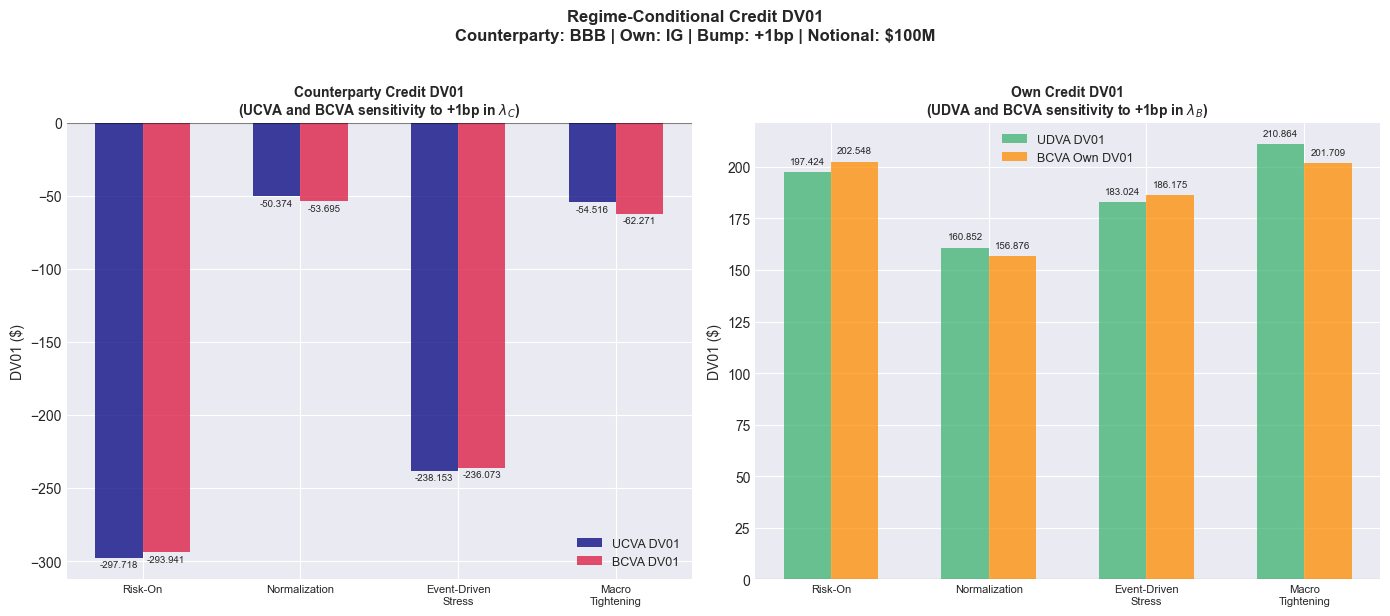

In [76]:
BUMP = 0.0001  # 1 basis point

credit_dv01_results = []

print("Credit DV01 Sensitivity")
print("="*75)
print(f"Bump: +{BUMP*10000:.0f} bps to counterparty $\lambda_C$")
print(f"Own Credit DV01: +{BUMP*10000:.0f} bps to own $\lambda_B$")
print("="*75)
print(f"\n{'Regime':<22} {'UCVA DV01':>12} "
      f"{'UDVA DV01':>12} {'BCVA DV01':>12} "
      f"{'Own DV01':>12}")
print("-"*75)

for regime in REGIME_ORDER:
    # Base hazard rates
    lam_cp = hazard_rates.loc[
        (hazard_rates['regime'] == regime) &
        (hazard_rates['rating'] == CP_RATING),
        'lambda'
    ].values[0]
    lam_own = hazard_rates.loc[
        (hazard_rates['regime'] == regime) &
        (hazard_rates['rating'] == OWN_RATING),
        'lambda'
    ].values[0]

    df_curve = regime_discount_curves[regime]
    epe = epe_profiles[regime]
    ene = ene_profiles[regime]

    # Base XVA
    ucva_base, udva_base, bcva_base = compute_xva(
        epe, ene, df_curve,
        lam_cp, lam_own, LGD
    )

    # Bumped counterparty lambda → UCVA and BCVA DV01
    ucva_bump, _, bcva_bump = compute_xva(
        epe, ene, df_curve,
        lam_cp + BUMP, lam_own, LGD
    )

    ucva_dv01 = ucva_bump - ucva_base
    bcva_dv01 = bcva_bump - bcva_base

    # UDVA DV01 (bumped own lambda)
    _, udva_bump, _ = compute_xva(
        epe, ene, df_curve,
        lam_cp, lam_own + BUMP, LGD
    )
    udva_dv01 = udva_bump - udva_base

    # Own Credit DV01 for BCVA
    _, _, bcva_own_bump = compute_xva(
        epe, ene, df_curve,
        lam_cp, lam_own + BUMP, LGD
    )
    own_dv01 = bcva_own_bump - bcva_base

    credit_dv01_results.append({
        'regime': regime,
        'ucva_dv01': ucva_dv01,
        'udva_dv01': udva_dv01,
        'bcva_dv01': bcva_dv01,
        'own_dv01': own_dv01,
    })

    print(f"{regime:<22} "
          f"{ucva_dv01:>12.4f} "
          f"{udva_dv01:>12.4f} "
          f"{bcva_dv01:>12.4f} "
          f"{own_dv01:>12.4f}")

dv01_df = pd.DataFrame(credit_dv01_results)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(REGIME_ORDER))
width = 0.3

# Plot 1: UCVA and BCVA DV01
ax1 = axes[0]
bars1 = ax1.bar(
    x - width/2,
    dv01_df['ucva_dv01'],
    width, label='UCVA DV01',
    color='navy', alpha=0.75
)
bars2 = ax1.bar(
    x + width/2,
    dv01_df['bcva_dv01'],
    width, label='BCVA DV01',
    color='crimson', alpha=0.75
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    [r.replace(' ', '\n') for r in REGIME_ORDER],
    fontsize=8
)
ax1.set_ylabel('DV01 ($)')
ax1.set_title(
    'Counterparty Credit DV01\n'
    '(UCVA and BCVA sensitivity to +1bp in $\lambda_C$)',
    fontsize=10, fontweight='bold'
)
ax1.legend(fontsize=9)
ax1.axhline(y=0, color='black',
            linewidth=0.8, alpha=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            h - 8 if h < 0 else h + 3,
            f'{h:.3f}',
            ha='center', va='bottom', fontsize=7
        )

# Plot 2: UDVA and Own DV01
ax2 = axes[1]
bars3 = ax2.bar(
    x - width/2,
    dv01_df['udva_dv01'],
    width, label='UDVA DV01',
    color='mediumseagreen', alpha=0.75
)
bars4 = ax2.bar(
    x + width/2,
    dv01_df['own_dv01'],
    width, label='BCVA Own DV01',
    color='darkorange', alpha=0.75
)

ax2.set_xticks(x)
ax2.set_xticklabels(
    [r.replace(' ', '\n') for r in REGIME_ORDER],
    fontsize=8
)
ax2.set_ylabel('DV01 ($)')
ax2.set_title(
    'Own Credit DV01\n'
    '(UDVA and BCVA sensitivity to +1bp in $\lambda_B$)',
    fontsize=10, fontweight='bold'
)
ax2.legend(fontsize=9)
ax2.axhline(y=0, color='black',
            linewidth=0.8, alpha=0.5)

for bars in [bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            h - 8 if h < 0 else h + 3,
            f'{h:.3f}',
            ha='center', va='bottom', fontsize=7
        )

plt.suptitle(
    'Regime-Conditional Credit DV01\n'
    f'Counterparty: BBB | Own: IG | '
    f'Bump: +1bp | Notional: $100M',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../data/processed/05_credit_dv01.png', dpi=150, bbox_inches='tight')
plt.show()

**UCVA DV01 is negative across all regimes**, confirming that an increase in counterparty hazard rate increases the CVA charge (i.e., makes UCVA more negative). Risk-On produces the largest UCVA DV01 in absolute terms (-$297.72), driven by the large and persistent EPE profile in that regime. By contrast, Normalization and Macro Tightening produce much smaller UCVA DV01 values (-$50.37 and -$54.52 respectively), consistent with the compressed EPE profiles generated under inverted yield curve conditions.

**UDVA DV01 is positive across all regimes**, confirming that an increase in own hazard rate increases the DVA benefit. Macro Tightening produces the largest UDVA DV01 ($210.86), reflecting the large |ENE| profile under declining forward-rate dynamics. The ordering of UDVA DV01 broadly follows the magnitude of regime-conditional ENE.

**BCVA DV01 closely tracks UCVA DV01**, while **Own DV01 closely tracks UDVA DV01**, with only small differences arising from the bilateral survival probability adjustment embedded in the BCVA framework. The relatively small gap between unilateral and bilateral DV01 measures suggests that first-order credit sensitivity is driven primarily by exposure asymmetry and hazard rate levels rather than survival adjustments.

**The ratio of |UCVA DV01| to UDVA DV01 varies meaningfully across regimes.** In Risk-On, |UCVA DV01| exceeds UDVA DV01, reflecting the dominance of positive exposure in a normal yield curve environment. In Normalization and Macro Tightening, the relationship reverses, with UDVA DV01 exceeding |UCVA DV01| due to the larger |ENE| profiles generated under inverted yield curve conditions.

From a hedging perspective, the Credit DV01 figures approximate the first-order CDS hedge sensitivity required to hedge the XVA position. For example, under Risk-On conditions, a 100bp increase in counterparty CDS spread would increase the CVA charge by approximately $29,772 (= $297.72 × 100), implying a larger counterparty credit hedge requirement in normal curve environments than in inverted curve regimes.

## Wrong Way Risk Discussion

The current framework assumes that exposure dynamics and default intensities are conditionally independent within each regime. While regime-dependent hazard rates partially capture macroeconomic dependence between market conditions and credit quality, the model does not explicitly incorporate dynamic wrong-way risk (WWR) between exposure and counterparty default.

In practice, wrong-way risk arises when counterparty credit quality deteriorates precisely when exposure increases. For example, during market stress environments, declining liquidity conditions and widening credit spreads may simultaneously increase both exposure volatility and counterparty default probability. This effect can materially amplify CVA relative to models assuming conditional independence.

The regime-based framework used here captures a first-order approximation of this relationship through jointly stressed exposure profiles and hazard rates under adverse regimes such as Event-Driven Stress and Macro Tightening. However, it does not model pathwise dependence between short rate realizations and default intensity dynamics.

A more advanced implementation could incorporate stochastic intensity models or correlated exposure-credit simulations, such as:

- Hull-White short rates coupled with CIR default intensity models,
- correlated Brownian drivers between market and credit factors,
- or structural credit models with macroeconomic state variables.

Such extensions would allow explicit quantification of wrong-way risk and potentially produce materially larger CVA estimates under stressed regimes.

In [79]:
# Save all XVA results, Credit DV01 sensitivities, and exposure profiles for use in Notebook 6 (Stress Testing).

# Save XVA results 
results_df.to_csv('../data/processed/xva_results.csv', index=False)

# Save Credit DV01
dv01_df.to_csv('../data/processed/credit_dv01.csv', index=False)

# Save exposure profiles
exposure_rows = []
time_mo = np.arange(1, N_STEPS+1) / 12

for regime in REGIME_ORDER:
    for i, t in enumerate(time_mo):
        exposure_rows.append({
            'regime': regime,
            'tenor': t,
            'epe': epe_profiles[regime][i],
            'ene': ene_profiles[regime][i],
        })

exposure_df = pd.DataFrame(exposure_rows)
exposure_df.to_csv('../data/processed/exposure_profiles.csv', index=False)